## <center> Prelims 2024
### <center> Mani Tyagi
#### <center> 200973108

In [8]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


The given system of initial value problem: 
\begin{align}
\frac{dL}{dt} &= f_1(L, X, Y) = -4\alpha X - 4800L, \\
\frac{dX}{dt} &= f_2(L, X, Y) = -5L(Y - 0.01) - 330X, \\
\frac{dY}{dt} &= f_3(L, X, Y) = 5LX - 330(Y - 0.1)
\end{align}

In [9]:
# Define the system of differential equations
def system(t, variables, alpha):
    
    L, X, Y = variables
    dL_dt = -4 * alpha * X - 4800 * L
    dX_dt = -5 * L * (Y - 0.01) - 330 * X
    dY_dt = 5 * L * X - 330 * (Y - 0.1)
    return [dL_dt, dX_dt, dY_dt]

### Part (a)

Code for testing the solver with $\alpha = 0.1$

In [10]:
# initial conditions
initial_conditions = [0.01, 0.01, 0.1]

# alpha
alpha = 0.1

#  time for which to solve the system
t_span = [0, 1]

# Solve the system of IVPs using solve_ivp
solution = solve_ivp(system, t_span, initial_conditions, args=(alpha,), method='RK45')

# Printing the solution
print("Time Points (t):\n", solution.t)
print("\nVariables (L, X, Y):")
for i, variable in enumerate(['\nL: ', '\nX: ', '\nY: ']):
    print(f"{variable} {solution.y[i]}")


Time Points (t):
 [0.00000000e+00 1.96184384e-04 3.92368769e-04 ... 9.98838744e-01
 9.99602312e-01 1.00000000e+00]

Variables (L, X, Y):

L:  [1.00000000e-02 3.90231334e-03 1.52253717e-03 ... 7.94883146e-07
 1.50476577e-06 2.65459683e-07]

X:  [1.00000000e-02 9.37255271e-03 8.78477568e-03 ... 8.00217925e-11
 1.51486485e-10 2.67241289e-11]

Y:  [0.1        0.10000006 0.10000008 ... 0.1        0.1        0.1       ]


### Part (b)

The IVP has three fixed points. If a solution reaches one of these fixed points, it stays there indefinitely.

$\textbf{First Fixed Point:}$ 
   $$(L_1, X_1, Y_1) = (0, 0, 0.1) $$

$\textbf{Second and Third Fixed Points:}$
   $$L_2 = 66 \sqrt{\frac{\alpha}{880000} - 1}, \quad X_2 = -\frac{1200}{\alpha} L_2, \quad Y_2 = 0.1 - \frac{200}{11\alpha} L_2^2 $$

   $$L_3 = -66 \sqrt{\frac{\alpha}{880000} - 1}, \quad X_3 = \frac{1200}{\alpha} L_3, \quad Y_3 = 0.1 - \frac{200}{11\alpha} L_3^2$$
   

Fixed points for alpha = 1000000.0:
Fixed Point 1: (0, 0, 0.1)
Fixed Point 2: (24.372115, -0.029247, 0.089200)
Fixed Point 3: (-24.372115, 0.029247, 0.089200)



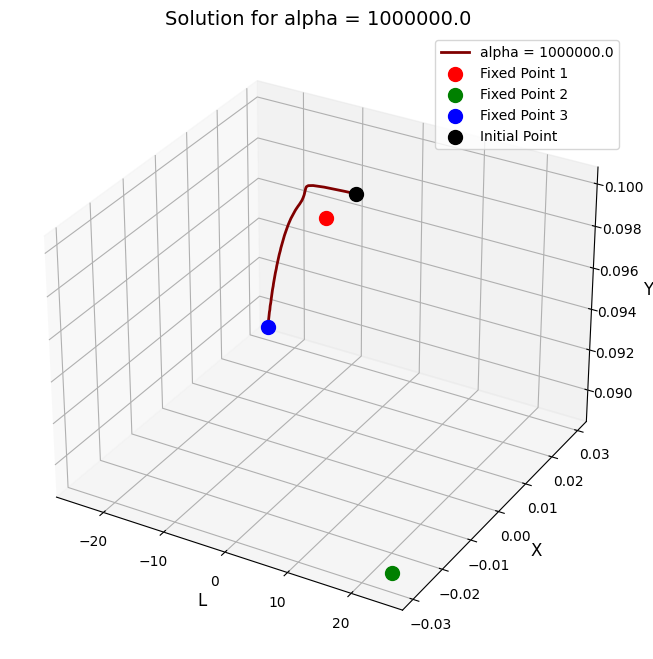

Fixed points for alpha = 3000000.0:
Fixed Point 1: (0, 0, 0.1)
Fixed Point 2: (102.440226, -0.040976, 0.036400)
Fixed Point 3: (-102.440226, 0.040976, 0.036400)



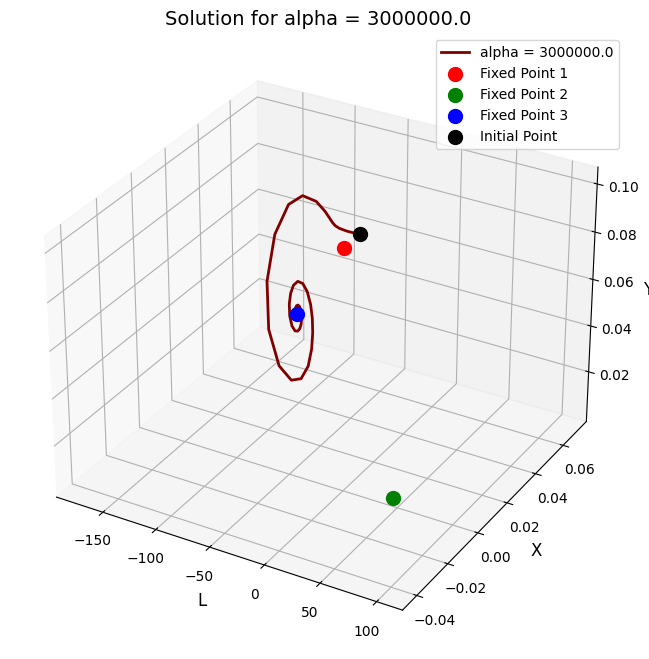

Fixed points for alpha = 20000000.0:
Fixed Point 1: (0, 0, 0.1)
Fixed Point 2: (307.642650, -0.018459, 0.013960)
Fixed Point 3: (-307.642650, 0.018459, 0.013960)



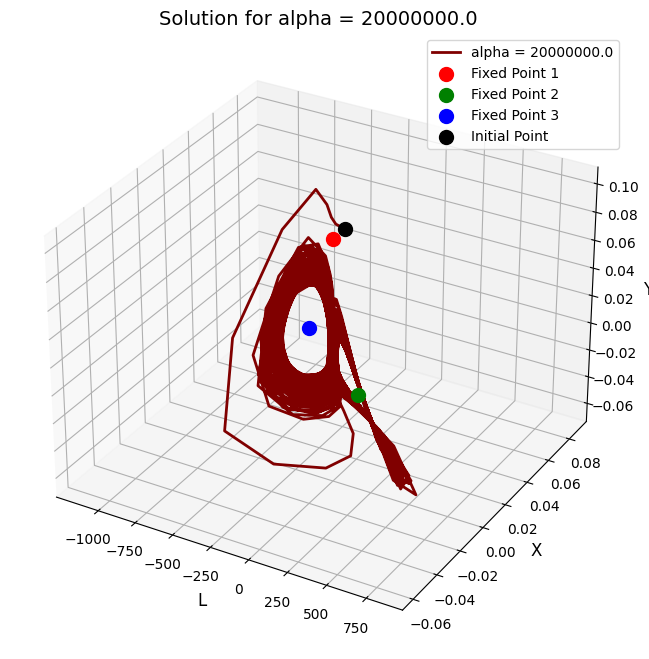

In [11]:
# initial conditions
initial_conditions = [0.01, 0.01, 0.1]

# values of alpha
alpha_values = [1e6, 3e6, 2e7]

# time points for which to solve the system
t_span = [0, 1]


# Loop over alpha values
for alpha in (alpha_values):
    
    # Solving the system of IVPs using solve_ivp
    solution = solve_ivp(system, t_span, initial_conditions, args=(alpha,), method='RK45')

    # plotting the solution for each alpha
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # three fixed points
    L1 = 0
    X1 = 0
    Y1 = 0.1
    
    print(f"Fixed points for alpha = {alpha}:")
    
    # Calculatin fixed points
    L_tilde = 66 * np.sqrt((alpha / 880000) - 1)
    L2 = L_tilde
    L3 = -L_tilde
    X2 = -(1200 / alpha) * L_tilde
    X3 = (1200 / alpha) * L_tilde
    Y2 = 0.1 - (200 / (11 * alpha)) * L_tilde ** 2
    Y3 = 0.1 - (200 / (11 * alpha)) * L_tilde ** 2
    
    # Printing fixed points
    print(f"Fixed Point 1: (0, 0, 0.1)")
    print(f"Fixed Point 2: ({L2:.6f}, {X2:.6f}, {Y2:.6f})")
    print(f"Fixed Point 3: ({L3:.6f}, {X3:.6f}, {Y3:.6f})")
    print()
    
    # Plotting the solution in 3D space
    ax.plot(solution.y[0], solution.y[1], solution.y[2], label=f'alpha = {alpha}', color='maroon', linewidth=2)
    ax.set_xlabel('L', fontsize=12)
    ax.set_ylabel('X', fontsize=12)
    ax.set_zlabel('Y', fontsize=12)
    ax.set_title(f'Solution for alpha = {alpha}', fontsize=14)
    ax.grid(True, which='both', linestyle=':', linewidth=0.5, color='gray', alpha=0.6)
    
    # plotting for fixed points and initial points
    fixed_points = [(0, 0, 0.1), (L2, X2, Y2), (L3, X3, Y3)]
    colors = ['r', 'g', 'b']
    for i, (L, X, Y) in enumerate(fixed_points):
        ax.scatter(L, X, Y, color=colors[i], marker='o', s=100, label=f'Fixed Point {i+1}')

    ax.scatter(initial_conditions[0], initial_conditions[1], initial_conditions[2], color='black', marker='o', s=100, label='Initial Point')
    ax.legend(fontsize=10)
    plt.show()

$\textbf{Behavior:}$
  - For $\alpha = 1 \times 10^6$, the system quickly stabilizes and stays at fixed point $(L_3, X_3, Y_3)$. Afterwords, it remains there for the entire timespan.

  - For $\alpha = 3 \times 10^6$, the system takes some time to stabilizes and then comes at fixed point $(L_3, X_3, Y_3)$. Afterwords, it remains there for the entire time span. The fixed points 2 and 3, in this case, are far away from the origin. Because of this the solution takes some time, oscillate and then reaches the fixed point 3.
  
  -   For $\alpha = 2 \times 10^7$, the fixed points $(L_2, X_2, Y_2)$ and $(L_3, X_3, Y_3)$ are significantly further from the origin compared to the other two cases. The trajectories will exhibit even more oscillatory behavior with larger amplitudes. The system takes longer to stabilize and oscillates more significantly before settling near the fixed point 2 (It appears to, at least! I am not sure if it is staying there because the perspective is not clear in plot).

$\textbf{Summary:}$

- As $\alpha$ increases, the fixed points $(L_2, X_2, Y_2)$ and $(L_3, X_3, Y_3)$ move further from the origin. The system exhibits more significant oscillatory behavior and takes longer to stabilize. 

- For lower values of $\alpha$, the system stabilizes more quickly and has lesser oscillations. For higher values, the system has larger oscillations and requires more time to approach the fixed points.

- Since the initial conditions are close to the first fixed point, the trajectories initially tend towards this point before oscillating around and eventually settles near the second or third fixed points depending on the value of $\alpha$.

### Part (c)

The given equations are:
$$
\begin{align}
\frac{dL}{dt} &= f_1(L, X, Y) = -4\alpha X - 4800L, \\
\frac{dX}{dt} &= f_2(L, X, Y) = -5L(Y - 0.01) - 330X, \\
\frac{dY}{dt} &= f_3(L, X, Y) = 5LX - 330(Y - 0.1)
\end{align}
$$

The Jacobian matrix \( J \) is given by:

$$
J =
\begin{bmatrix}
\frac{\partial f_1}{\partial L} & \frac{\partial f_1}{\partial X} & \frac{\partial f_1}{\partial Y} \\
\frac{\partial f_2}{\partial L} & \frac{\partial f_2}{\partial X} & \frac{\partial f_2}{\partial Y} \\
\frac{\partial f_3}{\partial L} & \frac{\partial f_3}{\partial X} & \frac{\partial f_3}{\partial Y}
\end{bmatrix}
$$

Calculating the partial derivatives:
\begin{align*}
\frac{\partial f_1}{\partial L} = -4800,  \quad \quad 
\frac{\partial f_1}{\partial X} = -4\alpha,  \quad \quad
\frac{\partial f_1}{\partial Y} = 0 \\
\\
\frac{\partial f_2}{\partial L} = -5(Y - 0.01), \quad
\frac{\partial f_2}{\partial X} = -330, \quad
\frac{\partial f_2}{\partial Y} = -5L \\
\\
\frac{\partial f_3}{\partial L} = 5X, \quad \quad
\frac{\partial f_3}{\partial X} = 5L, \quad 
\frac{\partial f_3}{\partial Y} = -330 \\
\end{align*}
<br>
Hence, the Jacobian matrix is
$$
J =\begin{bmatrix}
-4800 & -4\alpha & 0 \\
-5(Y - 0.01) & -330 & -5L \\
5X & 5L & -330
\end{bmatrix}
$$

### Part (d)

Following is the code to define Jacobian of matrix and then compute its eigenvalues for different values of $\alpha$.

In [13]:
# Defining the Jacobian matrix
def jacobian(L, X, Y, alpha):
    J = np.array([
        [-4800, -4*alpha, 0],
        [-5*(Y - 0.01), -330, -5*L],
        [5*X, 5*L, -330]
    ])
    return J

# Fixed points
fixed_points = [(L1, X1, Y1), (L2, X2, Y2), (L3, X3, Y3)]

# Values of alpha
alpha_values = [1e6, 3e6, 2e7]

# Loop over alpha values
for alpha in alpha_values:
    print("-"*60)
    print(f"Eigenvalues for alpha = {alpha}:")
    print("-"*60)
    
    for i, point in enumerate(fixed_points):
        L, X, Y = point
        
        # Computing the Jacobian matrix
        J = jacobian(L, X, Y, alpha)
        
        # Computing eigenvalues
        eigenvalues = np.linalg.eigvals(J)
        print(f"Fixed point {i+1}: {eigenvalues} ")
    
    print("-"*60)
    print("\n")

------------------------------------------------------------
Eigenvalues for alpha = 1000000.0:
------------------------------------------------------------
Fixed point 1: [-5171.76523684    41.76523684  -330.        ] 
Fixed point 2: [-4840.73095985   +0.j          -309.63452008+1571.69069758j
  -309.63452008-1571.69069758j] 
Fixed point 3: [-4840.73095985   +0.j          -309.63452008+1571.69069758j
  -309.63452008-1571.69069758j] 
------------------------------------------------------------


------------------------------------------------------------
Eigenvalues for alpha = 3000000.0:
------------------------------------------------------------
Fixed point 1: [-5789.162682   659.162682  -330.      ] 
Fixed point 2: [-4919.2619591    +0.j         -270.36902045+1634.7074718j
  -270.36902045-1634.7074718j] 
Fixed point 3: [-4919.2619591    +0.j         -270.36902045+1634.7074718j
  -270.36902045-1634.7074718j] 
------------------------------------------------------------


----------

### Part (e)

For this part I have taken help from https://eng.libretexts.org/Bookshelves/Industrial_and_Systems_Engineering/Chemical_Process_Dynamics_and_Controls_(Woolf)/10%3A_Dynamical_Systems_Analysis/10.04%3A_Using_eigenvalues_and_eigenvectors_to_find_stability_and_solve_ODEs

| Eigenvalue Type       | Stability | Oscillatory Behavior | Notation          |
|-----------------------|-----------|----------------------|-------------------|
| All Real and $+$      | Unstable  | None                 | Unstable Node     |
| All Real and $-$      | Stable    | None                 | Stable Node       |
| Mixed $+$ \& $-$ Real| Unstable  | None                 | Unstable Saddle Point |
| $+a + bi$             | Unstable  | Undamped             | Unstable Spiral   |
| $-a + bi$             | Stable    | Damped               | Stable Spiral     |
| $0 + bi$              | Unstable  | Undamped             | Circle            |


$\underline{\textbf{\large For \(\alpha = 1 \times 10^6\)}}$


- Fixed point 1: Eigenvalues have mixed + and - real parts, indicating instability. This is the reason that the solution never converges to this fixed point.
- Fixed points 2 and 3: They have complex eigenvalues with negative real parts, suggesting stability with damped oscillations.

$\underline{\textbf{\large For \(\alpha = 3 \times 10^6\)}}$

- Fixed point 1: Eigenvalues have mixed + and - real parts, indicating instability. This is in accordance with solution obtained in part (b). The solution never converges to this point.
- Fixed points 2 and 3: Similar to $\alpha = 1\times 10^6$, they have complex eigenvalues with negative real parts, suggesting stability with damped oscillations.

$\underline{\textbf{\large For \(\alpha = 2 \times 10^7\)}}$

- Fixed point 1: Eigenvalues are again mixed and hence not stable.
- Fixed points 2 and 3: They have complex eigenvalues with small real parts, suggesting instability with comparatively lesser damped oscillations. This can be understood from Fig-2 and . The oscillation stays for longer in $\alpha = 2\times 10^7$ case.

Overall, as the $\alpha$ value increases, the stability of the fixed points can change. The behavior of the system is also affected, with some fixed points exhibiting damped oscillations while others show undamped oscillations.